## Twitter Sentiment Analysis

In [1]:
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,LancasterStemmer
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from mlxtend.plotting import plot_confusion_matrix

## Importing the dataset

In [2]:
df = pd.read_csv(r"D:\Innomatics\Git_Uploads\twitter_sentiment_analysis\data\twitter_training.csv", header=None,
                 names=["tweet_id","entity","sentiment","tweet"])

In [3]:
df.head(5)

,tweet_id,entity,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.shape

(74682, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [6]:
df.isnull().sum()

tweet_id       0
entity         0
sentiment      0
tweet        686
dtype: int64

In [7]:
df.dropna(subset="tweet",inplace=True)

In [8]:
df.isnull().sum()

tweet_id     0
entity       0
sentiment    0
tweet        0
dtype: int64

In [9]:
df["sentiment"].value_counts()

sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

In [10]:
df[df["sentiment"] == "Irrelevant"]

,tweet_id,entity,sentiment,tweet
102,2418,Borderlands,Irrelevant,Appreciate the (sonic) concepts / praxis Valen...
103,2418,Borderlands,Irrelevant,Appreciate the (sound) concepts / practices th...
104,2418,Borderlands,Irrelevant,Evaluate the (sound) concepts / concepts of Va...
105,2418,Borderlands,Irrelevant,Appreciate the (sonic) concepts / praxis Valen...
106,2418,Borderlands,Irrelevant,Appreciate by the ( sonic ) electronic concept...
...,...,...,...,...
74035,9085,Nvidia,Irrelevant,This is all based on last quarter's earnings. ...
74036,9085,Nvidia,Irrelevant,Let's see how well they handle the next one wh...
74037,9085,Nvidia,Irrelevant,Good on them. This stuff all based on earnings...
74038,9085,Nvidia,Irrelevant,9 Good idea for them. This is all based on ear...


In [11]:
## Dropping the Irrevelant sentiment data as its not needed for our sentiment analysis

In [12]:
df = df[df["sentiment"] != "Irrelevant"].reset_index(drop=True)

In [13]:
df["sentiment"].value_counts()

sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

In [14]:
df_copy = df.copy()

In [15]:
df.drop(axis=0,columns="tweet_id",inplace= True)

In [16]:
## Assiging numbers for sentiment for faster computation

In [17]:
sentiment_num = {"Negative":0,"Neutral" : 1, "Positive":2}
df["sentiment"] = df["sentiment"].map(sentiment_num)
df["sentiment"].value_counts()

sentiment
0    22358
2    20655
1    18108
Name: count, dtype: int64

### Text Preprocessing

#### Testing

In [18]:
test = df["tweet"].sample().iloc[0]
test

'Gas traps... store.playstation.com /'

In [19]:
test = test.lower()

In [20]:
test = re.sub(r"http\S+|www\S+","",test) ## Removes Link
test = re.sub(r"@\w+|@+","",test) ## Removes Mentions
test = re.sub(r"<\S+","",test) ## Removes Tage
test = re.sub(r"\w\S+\.com\S+","",test) ## removes other .com text
test = re.sub(r"\w+\.\S+","",test)  ## removes site links
test =  re.sub(r"#","",test) ## Removes symbol
test

'gas   /'

In [21]:
spec_char = r"[^a-z!?\s]"
test = re.sub(spec_char,"",test)

In [22]:
sw = stopwords.words("english")

In [23]:
n_sw = ['don', "don't", 'couldn', 'aren', "aren't", "not", "couldn't",
        'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
        "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn',
        "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan',
        "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren',
        "weren't", 'won', "won't", 'wouldn', "wouldn't"]

p_sw = set(sw).difference(n_sw)

In [24]:
print("Total stopwords: ",len(sw))
print("Negative stopwords: ",len(n_sw))
print("Positive Stoprods: ",len(p_sw))

Total stopwords:  198
Negative stopwords:  38
Positive Stoprods:  160


In [25]:
ps = PorterStemmer()
la = LancasterStemmer()

In [26]:
## Tokenization
test = test.split()

In [27]:
test = [ps.stem(word) for word in test if word not in p_sw]
test

['ga']

In [28]:
test= " ".join(test)

In [29]:
test

'ga'

In [30]:
## Text Preprocessing Funsction
def text_preprocessing(tweet):
    ## Lower Case
    tweet = tweet.lower()
    ## Removing tags and links
    tweet = re.sub(r"http\S+|www\S+","",tweet) ## Removes Link
    tweet = re.sub(r"@\w+|@+","",tweet) ## Removes Mentions
    tweet = re.sub(r"<\S+","",tweet) ## Removes Tage
    tweet = re.sub(r"\w\S+\.com\S+","",tweet) ## removes other .com text
    tweet = re.sub(r"\w+\.\S+","",tweet)  ## removes site links
    tweet =  re.sub(r"#","",tweet) ## Removes symbol
    ## Remove punctuations
    spec_char = r"[^a-z!?\s]"
    tweet = re.sub(spec_char,"",tweet)
    ## Tokenization
    tweet = tweet.split()
    ## Steming and Pos Stopwords removal
    tweet = [ps.stem(word) for word in tweet if word not in p_sw]
    tweet = " ".join(tweet)
    
    return tweet

In [31]:
df["tweet"] = df["tweet"].apply(text_preprocessing)

In [32]:
df.sample(5)

,entity,sentiment,tweet
21750,AssassinsCreed,2,play assassin creed uniti last year thought ba...
59175,Nvidia,2,oh cool first nvidia video drop peopl play gam...
43272,CallOfDuty,2,play call duti black op ??? plot mindblow easi...
49567,GrandTheftAuto(GTA),0,rockstarsupport cant join fellow lobbi gta v o...
50800,MaddenNFL,0,talk gotta see slow menu


## Visualization

In [33]:
wc =WordCloud()

<Axes: >

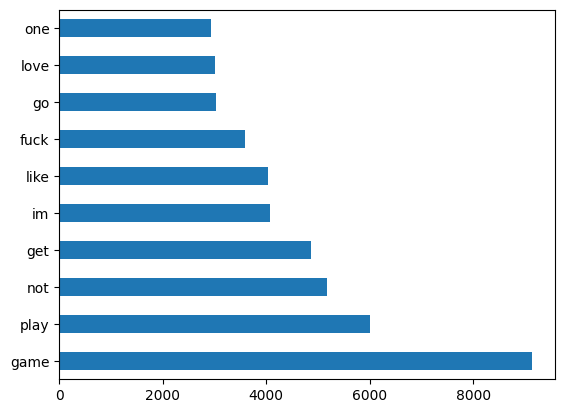

In [34]:
para = " ".join(df["tweet"])
words = pd.Series(para.split())
words.value_counts().head(10).plot(kind="barh")